# HJB, HJI, and Reachability Analysis

In the previous notebooks, Dynamic Programming was formulated in discrete time.

For a deterministic system:

$$
x_{k+1}=f(x_k,u_k),
$$

the Bellman recursion was:

$$
V_k(x)=
\min_u
\left[
\ell(x,u)
+
V_{k+1}(f(x,u))
\right].
$$

We now move to continuous-time systems:

$$
\dot{x}=f(x,u,t).
$$

The central question remains the same:

> What is the minimum future cost starting from the current state?

However, in continuous time there is no fixed next timestep $k+1$.

Instead, we apply the Dynamic Programming principle over a very small time interval:

$$
[t,t+\Delta t].
$$

Taking the limit:

$$
\Delta t \rightarrow 0
$$

leads to the **Hamilton-Jacobi-Bellman (HJB) equation**.

The main progression of this notebook is:

$$
\boxed{
\text{Discrete DP}
\rightarrow
\text{Continuous-Time DP}
\rightarrow
\text{HJB}
\rightarrow
\text{HJI}
\rightarrow
\text{Reachability}
}
$$

## 1. Dynamic Programming Over a Small Time Interval

Consider the continuous-time system:

$$
\dot{x}=f(x,u,t).
$$

The finite-horizon cost is:

$$
J=
\int_t^T
g(x(\tau),u(\tau),\tau)\,d\tau
+
h(x(T)).
$$

Define the value function:

$$
V(x,t)=
\text{minimum cost from state $x$ at time $t$ until $T$}.
$$

Using the principle of optimality over a small interval:

$$
[t,t+\Delta t],
$$

we write:

$$
\boxed{
V(x,t)=
\min_u
\left[
\int_t^{t+\Delta t}
g(x(\tau),u(\tau),\tau)\,d\tau
+
V(x(t+\Delta t),t+\Delta t)
\right].
}
$$

This is the continuous-time counterpart of the discrete Bellman recursion.

## 2. Small-Time Approximation

For a sufficiently small $\Delta t$:

$$
\int_t^{t+\Delta t}
g(x(\tau),u(\tau),\tau)\,d\tau
\approx
g(x,u,t)\Delta t.
$$

The state evolves approximately as:

$$
x(t+\Delta t)
\approx
x+f(x,u,t)\Delta t.
$$

Now Taylor-expand the value function:

$$
V(x(t+\Delta t),t+\Delta t)
$$

around $(x,t)$:

$$
V(x(t+\Delta t),t+\Delta t)
\approx
V(x,t)
+
\frac{\partial V}{\partial t}\Delta t
+
\nabla_xV^T f(x,u,t)\Delta t.
$$

## 3. Hamilton-Jacobi-Bellman Equation

Substituting the small-time approximations into the Bellman equation gives:

$$
V(x,t)=
\min_u
\left[
g(x,u,t)\Delta t
+
V(x,t)
+
\frac{\partial V}{\partial t}\Delta t
+
\nabla_xV^Tf(x,u,t)\Delta t
\right].
$$

Canceling $V(x,t)$ and dividing by $\Delta t$ gives:

$$
\boxed{
0=
\frac{\partial V}{\partial t}
+
\min_u
\left[
g(x,u,t)
+
\nabla_xV^Tf(x,u,t)
\right].
}
$$

This is the **Hamilton-Jacobi-Bellman equation**.

The terminal condition is:

$$
\boxed{
V(x,T)=h(x).
}
$$

Given the value function, the optimal control is:

$$
\boxed{
u^*(x,t)=
\arg\min_u
\left[
g(x,u,t)
+
\nabla_xV^Tf(x,u,t)
\right].
}
$$

## 4. HJB Applied to Continuous-Time LQR

Consider the linear continuous-time system:

$$
\dot{x}=Ax+Bu.
$$

We define the finite-horizon quadratic cost:

$$
J=
\frac{1}{2}x(T)^THx(T)
+
\frac{1}{2}
\int_t^T
\left(
x^TQx
+
u^TRu
\right)d\tau.
$$

The assumptions are:

$$
H \succeq 0,
\qquad
Q \succeq 0,
\qquad
R \succ 0.
$$

The objective is to find the feedback control $u(t)$ that minimizes the cost.

### Substituting the LQR Structure into HJB

For continuous-time LQR:

$$
g(x,u)=
\frac{1}{2}x^TQx
+
\frac{1}{2}u^TRu
$$

and:

$$
f(x,u)=Ax+Bu.
$$

Therefore, the HJB equation becomes:

$$
0=
\frac{\partial V}{\partial t}
+
\min_u
\left[
\frac{1}{2}x^TQx
+
\frac{1}{2}u^TRu
+
V_x^T(Ax+Bu)
\right].
$$

### Quadratic Value Function

Assume the value function has the form:

$$
\boxed{
V(x,t)=
\frac{1}{2}x^TP(t)x.
}
$$

Then:

$$
\boxed{
V_x=P(t)x
}
$$

and:

$$
\boxed{
V_t=
\frac{1}{2}
x^T\dot{P}(t)x.
}
$$

The terminal condition is:

$$
\boxed{
P(T)=H.
}
$$

### Optimal Continuous-Time Feedback Law

The terms involving $u$ are:

$$
\frac{1}{2}u^TRu
+
x^TPBu.
$$

Setting the derivative with respect to $u$ equal to zero:

$$
Ru+B^TPx=0.
$$

Therefore:

$$
\boxed{
u^*=
-R^{-1}B^TPx.
}
$$

Define:

$$
\boxed{
K(t)=R^{-1}B^TP(t).
}
$$

Then:

$$
\boxed{
u^*(t)=-K(t)x(t).
}
$$

### Continuous-Time Riccati Equation

Substituting the optimal control into the HJB equation gives:

$$
\boxed{
-\dot{P}=
A^TP
+
PA-
PBR^{-1}B^TP
+
Q.
}
$$

The terminal condition is:

$$
\boxed{
P(T)=H.
}
$$

This is the continuous-time Riccati differential equation.

It is solved backward in time:

$$
P(T)
\rightarrow
P(t)
\rightarrow
P(0).
$$

Once $P(t)$ is known, the feedback gain is:

$$
K(t)=R^{-1}B^TP(t)
$$

and the optimal controller is:

$$
u(t)=-K(t)x(t).
$$

## 5. Scalar Continuous-Time LQR

Consider the scalar system:

$$
\dot{x}=ax+bu.
$$

We define the finite-horizon cost:

$$
J=
\frac{1}{2}h\,x(T)^2
+
\frac{1}{2}
\int_0^T
\left(
q x^2+r u^2
\right)dt.
$$

For this scalar problem, the value function has the form:

$$
V(x,t)=
\frac{1}{2}P(t)x^2.
$$

The Riccati differential equation becomes:

$$
\boxed{
-\dot{P}=
2aP-
\frac{b^2}{r}P^2
+
q.
}
$$

with terminal condition:

$$
\boxed{
P(T)=h.
}
$$

Once $P(t)$ is known, the optimal feedback gain is:

$$
\boxed{
K(t)=\frac{b}{r}P(t)
}
$$

and the optimal control is:

$$
\boxed{
u(t)=-K(t)x(t).
}
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# System
a = 0.0
b = 1.0

# Cost weights
q = 1.0
r = 0.5
h = 10.0

# Horizon
T = 5.0

In [2]:
def riccati_rhs(t, P):
    return -(
        2.0 * a * P
        - (b**2 / r) * P**2
        + q
    )

In [3]:
num_points = 300

t_eval_backward = np.linspace(T, 0.0, num_points)

solution = solve_ivp(
    riccati_rhs,
    t_span=(T, 0.0),
    y0=[h],
    t_eval=t_eval_backward
)

# Reverse so time runs forward for plotting/use
time = solution.t[::-1]
P = solution.y[0][::-1]

K = (b / r) * P

### Backward Riccati Solution

The Riccati equation is integrated from:

$$
P(T)=h
$$

backward toward:

$$
P(0).
$$

This gives a time-dependent value-function coefficient:

$$
P(t)
$$

and therefore a time-dependent feedback gain:

$$
K(t)=\frac{b}{r}P(t).
$$

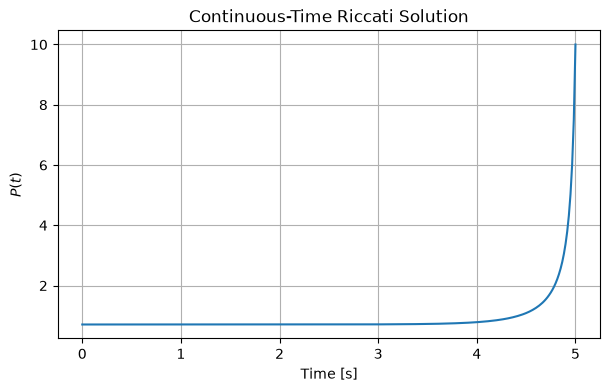

In [5]:
plt.figure(figsize=(7, 4))
plt.plot(time, P)
plt.xlabel("Time [s]")
plt.ylabel("$P(t)$")
plt.title("Continuous-Time Riccati Solution")
plt.grid(True)
plt.show()

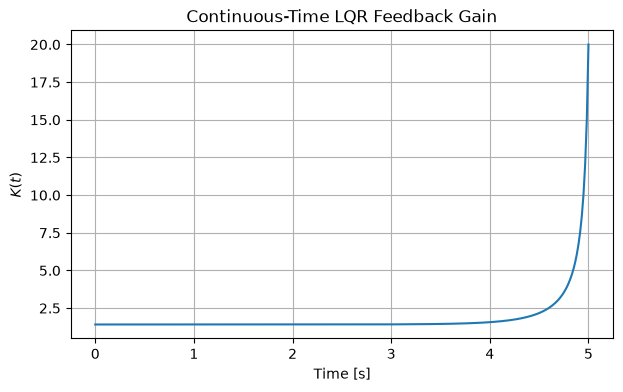

In [6]:
plt.figure(figsize=(7, 4))
plt.plot(time, K)
plt.xlabel("Time [s]")
plt.ylabel("$K(t)$")
plt.title("Continuous-Time LQR Feedback Gain")
plt.grid(True)
plt.show()

In [7]:
def gain_at_time(t):
    return np.interp(t, time, K)


def closed_loop_rhs(t, x):
    k = gain_at_time(t)
    u = -k * x[0]

    dx = a * x[0] + b * u

    return [dx]

In [8]:
x0 = [5.0]

closed_loop_solution = solve_ivp(
    closed_loop_rhs,
    t_span=(0.0, T),
    y0=x0,
    t_eval=time
)

X = closed_loop_solution.y[0]

U = np.array([
    -gain_at_time(t) * x
    for t, x in zip(time, X)
])

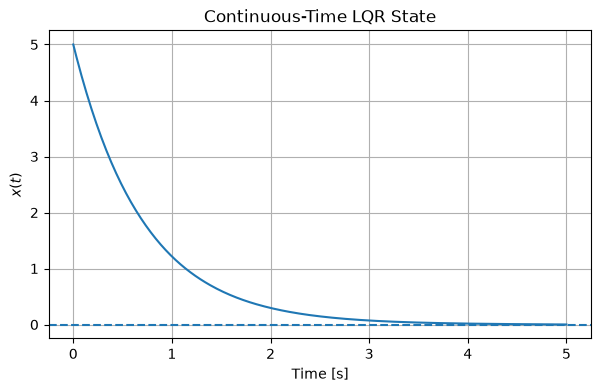

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(time, X)
plt.axhline(0.0, linestyle="--")
plt.xlabel("Time [s]")
plt.ylabel("$x(t)$")
plt.title("Continuous-Time LQR State")
plt.grid(True)
plt.show()

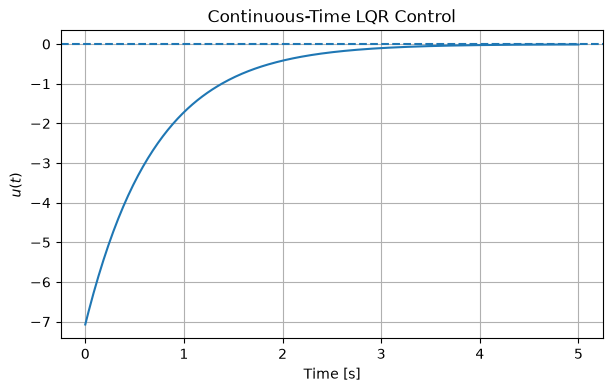

In [10]:
plt.figure(figsize=(7, 4))
plt.plot(time, U)
plt.axhline(0.0, linestyle="--")
plt.xlabel("Time [s]")
plt.ylabel("$u(t)$")
plt.title("Continuous-Time LQR Control")
plt.grid(True)
plt.show()

### Observation

The state is driven toward the desired equilibrium:

$$
x(t)\rightarrow0.
$$

The control is determined continuously by:

$$
u(t)=-K(t)x(t).
$$

The feedback gain is obtained from the Riccati equation:

$$
K(t)=\frac{b}{r}P(t).
$$

Thus the continuous-time LQR workflow is:

$$
\boxed{
P(T)
\rightarrow
\text{integrate Riccati equation backward}
\rightarrow
K(t)
\rightarrow
u(t)=-K(t)x(t)
}
$$

## 6. From HJB to HJI

The HJB equation assumes that only the controller chooses an input.

Consider instead dynamics of the form:

$$
\dot{x}=
f(x,u,d,t),
$$

where:

- $u$ is the control input,
- $d$ is a disturbance or adversarial input.

The controller attempts to reduce the cost, while the disturbance is assumed to act in the worst possible way.

This creates a two-player differential game:

$$
\boxed{
\text{controller}
\quad\text{vs.}\quad
\text{disturbance}.
}
$$

Conceptually:

$$
u
\rightarrow
\text{minimize cost}
$$

while:

$$
d
\rightarrow
\text{maximize cost}.
$$

### Differential-Game Value Function

Suppose the cost is:

$$
J=
\int_t^T
g(x,u,d,\tau)\,d\tau
+
h(x(T)).
$$

The controller tries to minimize this cost, while the disturbance tries to maximize it.

Over a small time interval, the Dynamic Programming principle becomes:

$$
V(x,t)=
\min_u
\max_d
\left[
\int_t^{t+\Delta t}
g(x,u,d,\tau)\,d\tau
+
V(x(t+\Delta t),t+\Delta t)
\right].
$$

## 7. Hamilton-Jacobi-Isaacs Equation

Applying the same small-time approximation used for HJB gives:

$$
\boxed{
0=
\frac{\partial V}{\partial t}
+
\min_u
\max_d
\left[
g(x,u,d,t)
+
\nabla_xV^T
f(x,u,d,t)
\right].
}
$$

This is the **Hamilton-Jacobi-Isaacs (HJI) equation**.

The expression:

$$
g(x,u,d,t)
+
\nabla_xV^Tf(x,u,d,t)
$$

is commonly called the **Hamiltonian**.

The optimal controller selects:

$$
u^*=
\arg\min_u
\max_d
\left[
g
+
\nabla_xV^Tf
\right],
$$

while the disturbance acts in the opposing direction.

### Interpretation of the Min-Max Structure

For a simple system:

$$
\dot{x}=u+d,
$$

the HJI Hamiltonian contains:

$$
V_x(u+d).
$$

If:

$$
V_x>0,
$$

then increasing $x$ increases the value.

A minimizing controller therefore prefers a negative control, while a maximizing disturbance prefers a positive disturbance.

Thus the HJI equation determines both:

$$
\boxed{
\text{best control action}
}
$$

and:

$$
\boxed{
\text{worst-case disturbance action}.
}
$$

## 8. Target Sets and Backward Reachability

In reachability analysis, the objective is no longer necessarily to minimize an accumulated running cost.

Instead, we define a **target set**:

$$
\mathcal{T}.
$$

The target set can represent:

- an unsafe region,
- a collision region,
- a desired goal region.

We encode membership in the target set using a terminal function:

$$
h(x).
$$

The function is chosen such that:

$$
\boxed{
x\in\mathcal{T}
\iff
h(x)\leq0.
}
$$

For example, for a circular target region centered at the origin:

$$
\mathcal{T}=
\left\{
x:
x_1^2+x_2^2\leq R^2
\right\},
$$

we can choose:

$$
\boxed{
h(x)=
x_1^2+x_2^2-R^2.
}
$$

Then:

$$
h(x)\leq0
$$

exactly corresponds to being inside the target set.

## 9. Backward Reachable Set

Suppose the target set is:

$$
\mathcal{T}.
$$

The **Backward Reachable Set (BRS)** at time $t$ contains states from which the system can reach the target set by the terminal time.

Conceptually:

$$
\boxed{
\mathcal{R}(t)=
\text{states that can lead to } \mathcal{T}
}
$$

under the specified control and disturbance assumptions.

The HJI value function provides an implicit representation of this set:

$$
\boxed{
\mathcal{R}(t)=
\{x:V(x,t)\leq0\}.
}
$$

Thus:

$$
V(x,t)>0
$$

and:

$$
V(x,t)\leq0
$$

separate states according to whether they belong to the reachable set.

### Avoidance and Goal Reachability

The same reachability machinery can be used for different objectives.

### Avoidance

Let:

$$
\mathcal{T}=
\text{unsafe set}.
$$

The backward reachable set represents states that can lead to danger under the worst-case disturbance.

This can be used to determine whether safety can still be guaranteed.

### Goal Reachability

Let:

$$
\mathcal{T}=
\text{goal set}.
$$

The backward reachable set can instead represent states from which the controller can guarantee reaching the goal despite disturbances.

Therefore, the meaning of the reachable set depends on:

1. the definition of the target set,
2. which player minimizes,
3. which player maximizes.

## 10. HJI for Reachability

For reachability analysis, the running cost can be removed:

$$
g(x,u,d)=0.
$$

The HJI equation then becomes:

$$
\boxed{
0=
\frac{\partial V}{\partial t}
+
\min_u
\max_d
\left[
\nabla_xV^T
f(x,u,d)
\right].
}
$$

The terminal condition is:

$$
\boxed{
V(x,T)=h(x)
}
$$

where:

$$
x\in\mathcal{T}
\iff
h(x)\leq0.
$$

Solving the HJI equation backward in time propagates the target set through the system dynamics.

The backward reachable set is extracted as:

$$
\boxed{
\mathcal{R}(t)=
\{x:V(x,t)\leq0\}.
}
$$

## 11. A Simple 1D Reachability Example

Consider the system:

$$
\dot{x}=u+d
$$

with bounded control and disturbance:

$$
|u|\leq u_{\max}
$$

and:

$$
|d|\leq d_{\max}.
$$

Let the unsafe target set be the interval:

$$
\mathcal{T}=
\{x:|x|\leq R\}.
$$

We encode this set using:

$$
\boxed{
h(x)=|x|-R
}
$$

so that:

$$
x\in\mathcal{T}
\iff
h(x)\leq0.
$$

The reachability question is:

> From which initial states can the system be driven into the unsafe interval within the available time horizon under the assumed controller-disturbance game?

### Geometric Interpretation

Suppose:

$$
d_{\max}>u_{\max}.
$$

Under the worst-case disturbance, the disturbance can overcome the controller by approximately:

$$
v_{\text{net}}=
d_{\max}-u_{\max}.
$$

Over a backward time horizon $\tau$, the unsafe set expands approximately by:

$$
v_{\text{net}}\tau.
$$

Therefore:

$$
\boxed{
\mathcal{R}(-\tau)
\approx
\left[
-R-v_{\text{net}}\tau,
\;
R+v_{\text{net}}\tau
\right].
}
$$

The farther backward in time we look, the larger the set of states from which the unsafe region can potentially be reached.

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Problem parameters
R = 1.0

u_max = 1.0
d_max = 1.5

T = 4.0

# Net worst-case speed toward unsafe set
v_net = max(d_max - u_max, 0.0)

# Backward times
taus = np.linspace(0.0, T, 100)

left_boundary = -R - v_net * taus
right_boundary = R + v_net * taus

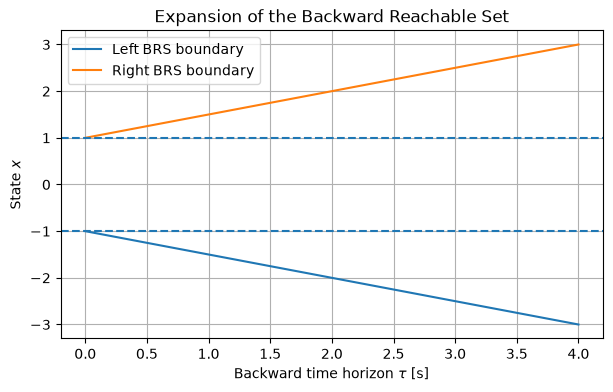

In [12]:
plt.figure(figsize=(7, 4))

plt.plot(taus, left_boundary, label="Left BRS boundary")
plt.plot(taus, right_boundary, label="Right BRS boundary")

plt.axhline(-R, linestyle="--")
plt.axhline(R, linestyle="--")

plt.xlabel("Backward time horizon $\\tau$ [s]")
plt.ylabel("State $x$")
plt.title("Expansion of the Backward Reachable Set")
plt.legend()
plt.grid(True)
plt.show()

### Reachable-Set Evolution

At terminal time:

$$
\tau=0,
$$

the backward reachable set is exactly the target set:

$$
\mathcal{R}(0)=\mathcal{T}.
$$

As the solution is propagated backward:

$$
\tau>0,
$$

the reachable set expands.

Thus:

$$
\boxed{
\text{target set at terminal time}
\rightarrow
\text{larger backward reachable set}
}
$$

The BRS contains states that may eventually enter the unsafe set under the specified worst-case disturbance model.

## 12. Value Function as an Implicit Set Representation

For the 1D example, an approximate reachability value function is:

$$
V(x,-\tau)=
|x|-
\left(
R+v_{\text{net}}\tau
\right).
$$

The backward reachable set is then:

$$
\boxed{
\mathcal{R}(-\tau)=
\{x:V(x,-\tau)\leq0\}.
}
$$

The boundary satisfies:

$$
V(x,-\tau)=0.
$$

Thus the HJI value function provides an implicit geometric description of the reachable set.

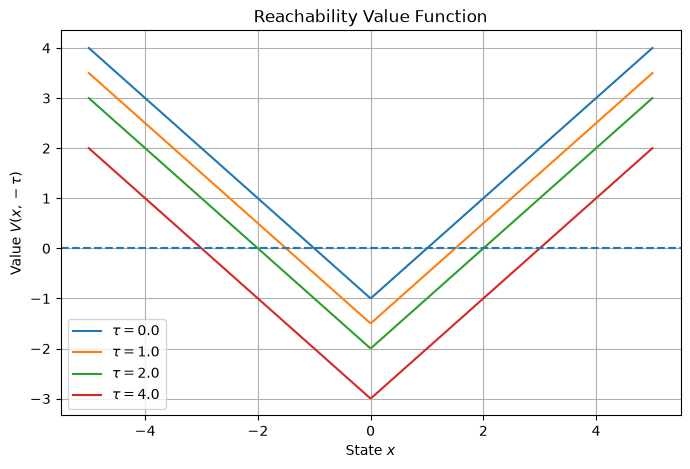

In [13]:
x_grid = np.linspace(-5.0, 5.0, 400)

backward_times = [0.0, 1.0, 2.0, 4.0]

plt.figure(figsize=(8, 5))

for tau in backward_times:

    V = (
        np.abs(x_grid)
        - (R + v_net * tau)
    )

    plt.plot(
        x_grid,
        V,
        label=f"$\\tau={tau}$"
    )

plt.axhline(0.0, linestyle="--")

plt.xlabel("State $x$")
plt.ylabel("Value $V(x,-\\tau)$")
plt.title("Reachability Value Function")
plt.legend()
plt.grid(True)
plt.show()

## 13. Computational Limitation

Hamilton-Jacobi reachability typically represents the value function on a state-space grid.

If each of $n_x$ state dimensions is discretized into $m$ points, the grid contains approximately:

$$
m^{n_x}
$$

states.

Therefore:

$$
\boxed{
\text{HJ reachability also suffers from the curse of dimensionality}.
}
$$

This makes exact grid-based HJI methods particularly suitable for systems with relatively small state dimension.

## 14. Reachability for Safety

Suppose the target set represents an unsafe region:

$$
\mathcal{T}=
\text{collision or failure states}.
$$

Solving the HJI reachability problem backward in time produces a backward reachable set:

$$
\mathcal{R}(t).
$$

This set identifies states from which the unsafe region can be reached under the assumed worst-case disturbance.

The value function provides an implicit representation:

$$
\mathcal{R}(t)=
\{x:V(x,t)\leq0\}.
$$

The boundary:

$$
V(x,t)=0
$$

separates states according to the reachability analysis.

The HJI solution can also provide a control policy designed to oppose the worst-case evolution toward the unsafe set.

## 15. Reachability as a Safety Filter

The reachability controller does not necessarily need to control the system at all times.

Suppose another controller provides:

$$
u_{\text{nominal}}.
$$

This controller may come from:

- trajectory tracking,
- MPC,
- iLQR,
- a learned policy.

The HJI value function can be used to monitor safety.

Conceptually:

$$
\boxed{
u=
\begin{cases}
u_{\text{nominal}},
&
\text{away from the safety boundary}
\\[4pt]
u_{\text{safety}},
&
\text{when safety intervention is required}.
\end{cases}
}
$$

Thus reachability analysis can act as a protective layer around a nominal controller.

```text

                 ┌─────────────────┐
                 │ Nominal planner │
                 │ MPC / iLQR / RL │
                 └────────┬────────┘
                          │
                     u_nominal
                          │
                          ▼
                  ┌───────────────┐
Current state ──► │ Safety filter │
                  │   HJI / BRS   │
                  └───────┬───────┘
                          │
                     safe control
                          │
                          ▼
                       Robot

## 16. Optimal Control vs Reachability

The methods studied so far answer different questions.

### LQR / iLQR

Typical question:

> Which controls minimize a trajectory cost?

For example:

$$
J=
\phi(x_N)
+
\sum_k \ell(x_k,u_k).
$$

The result is an optimal control policy or trajectory.

### HJB

Typical question:

> What is the optimal continuous-time cost-to-go?

The value function satisfies:

$$
V_t+
\min_u
\left[
g+\nabla V^Tf
\right]
=0.
$$

### HJI Reachability

Typical question:

> Which states can reach a target set under competing control and disturbance actions?

The target may represent:

$$
\text{goal}
$$

or:

$$
\text{unsafe region}.
$$

The result is a value function whose level sets represent reachable regions.

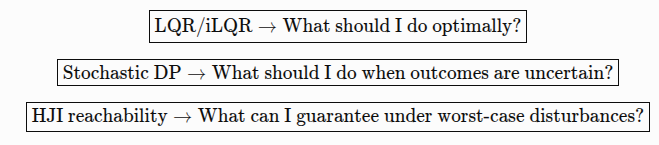

## 17. Main Takeaway

The progression of this notebook was:

$$
\boxed{
\text{Bellman Principle}
\rightarrow
\text{HJB}
\rightarrow
\text{HJI}
\rightarrow
\text{Reachability}
}
$$

### HJB

Continuous-time Dynamic Programming leads to:

$$
0=
V_t
+
\min_u
\left[
g+\nabla V^Tf
\right].
$$

For linear dynamics and quadratic costs, HJB reduces to the continuous-time Riccati equation.

### HJI

Introducing a disturbance or adversarial input:

$$
\dot{x}=f(x,u,d)
$$

creates a differential game.

The controller and disturbance optimize in opposing directions, producing a min-max or max-min HJI equation depending on the game formulation.

### Reachability

A target set can be represented implicitly using:

$$
h(x)\leq0.
$$

Solving the corresponding HJI problem backward propagates this target through the dynamics.

The value function represents the reachable set:

$$
\boxed{
\mathcal{R}(t)=
\{x:V(x,t)\leq0\}.
}
$$

For an unsafe target set, this provides a way to reason about states that may lead to danger under worst-case disturbances.

The associated HJI policy can then be used as a safety controller around a nominal controller.

### Central Insight

HJB and HJI are not separate ideas from Dynamic Programming.

They are continuous-time forms of the same Bellman principle:

$$
\boxed{
\text{make the current decision while accounting for the future value}.
}
$$

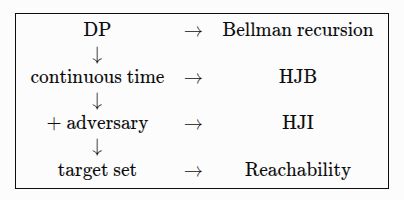